In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
!pip install pytorch-fid pillow tqdm

In [ ]:
# Imports and device setup
import math
import time
import functools
import tempfile
from pathlib import Path

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)

Using device: cuda


I use the variance-exploding SDE: dX_t = sigma^t dW_t.

For this SDE, the perturbation kernel p_{0t}(x(t) | x(0)) is Gaussian, so
its standard deviation can be written in closed form. This lets us sample
noisy training inputs directly, and scale the network output appropriately across noise levels.

In [ ]:
# Standard deviation of p_{0t}(x(t) | x(0)) for the VE SDE.
# Used for corrupting training data and for sampling the initial noise at t=1.
def marginal_prob_std(t, sigma):
    t = t.to(device)
    return torch.sqrt((sigma**(2 * t) - 1.) / (2. * math.log(sigma)))

# Diffusion coefficient g(t) = sigma^t
def diffusion_coeff(t, sigma):
    t = t.to(device)
    return sigma**t

sigma = 25.0  # as in the tutorial
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn   = functools.partial(diffusion_coeff,   sigma=sigma)


The score network architecture is divided into 3 pieces:
 1. GaussianFourierProjection: encodes scalar time t with sin/cos features.
 2. TimeMLP / ResidualBlock: standard time-conditioned residual block.
 3. U-Net-style encoder/decoder that estimates the score.

In [ ]:
# Gaussian Fourier features for time embedding.
class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim=128, scale=30.):
        super().__init__()
        self.embed_dim = embed_dim
        self.scale = scale
        # Random frequencies, fixed (not learned).
        self.register_buffer("W", torch.randn(embed_dim // 2) * scale)

    def forward(self, t):
        t = t.view(-1, 1)
        proj = t * self.W[None, :] * 2 * math.pi
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)


#  Multilayer perceptron converting time embedding to per-channel bias.
class TimeMLP(nn.Module):
    def __init__(self, time_embed_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(time_embed_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, t_emb):
        return self.net(t_emb)


# Residual conv block with time conditioning. The time embedding is converted
# into a channel-wise bias and added to the feature map
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_embed_dim, groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.time_mlp = TimeMLP(time_embed_dim, out_channels)
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)
        # Inject time as channel-wise bias.
        h = h + self.time_mlp(t_emb)[..., None, None]
        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)
        return h + self.skip(x)

# Time-dependent score network s_theta(x, t) for MNIST.
# Small U-Net: encoder extracts "rough" features, bottleneck processes the
# compressed representation, decoder reconstructs spatial detail using skip connections.
class ScoreNet(nn.Module):
    def __init__(self, marginal_prob_std, time_embed_dim=128, base_channels=32):
        super().__init__()
        self.marginal_prob_std = marginal_prob_std
        self.time_embed = GaussianFourierProjection(embed_dim=time_embed_dim)

        # Encoder
        self.conv_in = nn.Conv2d(1, base_channels, 3, padding=1)
        self.res1 = ResidualBlock(base_channels, base_channels, time_embed_dim)
        self.down1 = nn.Conv2d(base_channels, base_channels * 2, 4, stride=2, padding=1)

        self.res2 = ResidualBlock(base_channels * 2, base_channels * 2, time_embed_dim)
        self.down2 = nn.Conv2d(base_channels * 2, base_channels * 4, 4, stride=2, padding=1)

        # Bottleneck
        self.res3 = ResidualBlock(base_channels * 4, base_channels * 4, time_embed_dim)

        # Decoder
        self.up1 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, stride=2, padding=1)
        self.res4 = ResidualBlock(base_channels * 4, base_channels * 2, time_embed_dim)

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, 4, stride=2, padding=1)
        self.res5 = ResidualBlock(base_channels * 2, base_channels, time_embed_dim)

        self.conv_out = nn.Conv2d(base_channels, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        # Encoder
        h1 = self.conv_in(x)
        h1 = self.res1(h1, t_emb)
        h2 = self.down1(h1)
        h2 = self.res2(h2, t_emb)
        h3 = self.down2(h2)
        h3 = self.res3(h3, t_emb)

        # Decoder with skip connections
        u1 = self.up1(h3)
        u1 = torch.cat([u1, h2], dim=1)
        u1 = self.res4(u1, t_emb)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, h1], dim=1)
        u2 = self.res5(u2, t_emb)

        out = self.conv_out(u2)
        # Rescale by 1 / std(t) as in the tutorial.
        std = self.marginal_prob_std(t)
        return out / std[:, None, None, None]


In [ ]:
# Continuous-time denoising score matching loss.
# Sample a random time t, corrupt clean data x with Gaussian noise at
# that time, and ask the network to estimate the score of the noisy
# distribution. For the VE SDE the perturbation kernel is Gaussian, so
# its score is known analytically, that's what we train against.

def loss_fn(model, x, marginal_prob_std, eps=1e-5):
    random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
    z = torch.randn_like(x)
    std = marginal_prob_std(random_t)
    perturbed_x = x + z * std[:, None, None, None]
    score = model(perturbed_x, random_t)
    loss = torch.mean(torch.sum((score * std[:, None, None, None] + z)**2,
                                dim=(1, 2, 3)))
    return loss

In [ ]:
# Data loading

transform = transforms.ToTensor()
train_dataset = MNIST(root=".", train=True,  transform=transform, download=True)
test_dataset  = MNIST(root=".", train=False, transform=transform, download=True)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)}  Test: {len(test_dataset)}")

Train: 60000  Test: 10000


In [ ]:
# Each epoch draws minibatches of clean MNIST images, corrupts them at
# random times t, and trains the network to estimate the corresponding
# score. Runs for 15 epochs.

score_model = ScoreNet(marginal_prob_std=marginal_prob_std_fn).to(device)
optimizer = torch.optim.Adam(score_model.parameters(), lr=1e-4)

n_epochs = 15
train_losses = []
score_model.train()

for epoch in range(1, n_epochs + 1):
    running_loss = 0.0
    num_batches = 0

    for x, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{n_epochs}"):
        x = x.to(device)
        optimizer.zero_grad()
        loss = loss_fn(score_model, x, marginal_prob_std_fn)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        num_batches += 1

    avg_loss = running_loss / num_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch}: loss = {avg_loss:.4f}")

    # Save a checkpoint every 5 epochs.
    if epoch % 5 == 0:
        torch.save(score_model.state_dict(), f"mnist_score_model_epoch{epoch}.pt")


Epoch 1/15: 100%|██████████| 1875/1875 [00:07<00:00, 248.83it/s]


Epoch 1: loss = 40.4493


Epoch 2/15: 100%|██████████| 1875/1875 [00:07<00:00, 244.20it/s]


Epoch 2: loss = 18.8427


Epoch 3/15: 100%|██████████| 1875/1875 [00:08<00:00, 233.24it/s]


...

Epoch 13: loss = 13.8175


Epoch 14/15: 100%|██████████| 1875/1875 [00:07<00:00, 255.48it/s]


Epoch 14: loss = 13.7261


Epoch 15/15: 100%|██████████| 1875/1875 [00:07<00:00, 240.94it/s]

Epoch 15: loss = 13.7296


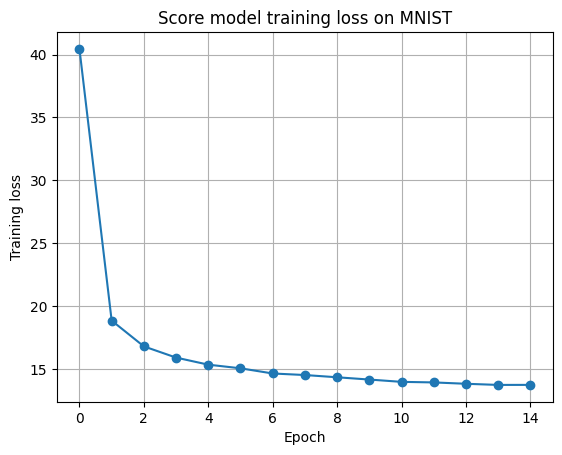

In [ ]:
# Plot the training loss

plt.figure()
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Score model training loss on MNIST")
plt.grid(True)
plt.show()

In [ ]:
# a sample visualization helper

def show_samples(samples, nrow=8, title="Generated Samples"):
    samples = samples[:nrow * nrow]
    grid = torch.zeros(1, nrow * 28, nrow * 28)
    idx = 0
    for i in range(nrow):
        for j in range(nrow):
            grid[:, i*28:(i+1)*28, j*28:(j+1)*28] = samples[idx]
            idx += 1
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.squeeze(0), cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.show()

In [ ]:
# Euler–Maruyama sampler
# Reverse SDE sampler. Starts from x(T), which is almost pure Gaussian noise and moves
# backward toward t=0. At each stepm the score network provides the drift
# direction and a Gaussian term accounts for the stochasticity of the reverse
# diffusion. Euler–Maruyama is first-order, so quality depends on the number
# of steps.
# The `show_progress` flag silences the inner per-step progress bar; useful when
# this sampler is called many times in a row (e.g. during the FID sweep)

@torch.no_grad()
def euler_maruyama_sampler(score_model,
                           marginal_prob_std,
                           diffusion_coeff,
                           batch_size=64,
                           num_steps=500,
                           device=device,
                           eps=1e-3,
                           show_progress=True):

    score_model.eval()

    t = torch.ones(batch_size, device=device)
    init_x = torch.randn(batch_size, 1, 28, 28, device=device) \
             * marginal_prob_std(t)[:, None, None, None]

    time_steps = torch.linspace(1., eps, num_steps, device=device)
    step_size = time_steps[0] - time_steps[1]

    x = init_x
    iterator = tqdm(time_steps, desc="Sampling") if show_progress else time_steps
    for time_step in iterator:
        batch_t = torch.ones(batch_size, device=device) * time_step
        g = diffusion_coeff(batch_t)
        # Reverse SDE: x_{t-dt} = x_t + g(t)^2 s_theta(x_t, t) dt + g(t) sqrt(dt) z_t
        score = score_model(x, batch_t)
        mean_x = x + (g**2)[:, None, None, None] * score * step_size
        z = torch.randn_like(x)
        x = mean_x + torch.sqrt(step_size) * g[:, None, None, None] * z

    # Return the noiseless mean for the final step.
    return mean_x

How to evaluate sample quality? Fréchet Inception Distance (FID) measures the similarity between generated images and real images. It calculates the distance between feature distributions of real and fake images in a deep learning model's feature space. Lower scores indicate better quality and diversity.

In [ ]:
# Frechet Inception distance compares two image distributions in InceptionV3 feature space.
# PS: FID values on MNIST are NOT directly comparable to CIFAR-10 FIDs
# from the paper. InceptionV3 was trained on natural images. Relative
# comparisons across our own sampler configurations ARE valid.

from pytorch_fid.inception import InceptionV3
from pytorch_fid.fid_score import calculate_frechet_distance

_FID_INCEPTION = None
_FID_REAL_STATS = None


def _get_inception(device):
    global _FID_INCEPTION
    if _FID_INCEPTION is None:
        block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
        _FID_INCEPTION = InceptionV3([block_idx]).to(device).eval()
    return _FID_INCEPTION

# Compute Inception (mu, sigma) for an in-memory tensor batch.
# Images are (N, 1, 28, 28) in [0, 1].
# I replicate to 3 channels and resize to 299x299 to match InceptionV3's expected input.
@torch.no_grad()
def _compute_stats_from_tensor(images, device, batch_size=50):
    model = _get_inception(device)
    features = []
    for start in range(0, len(images), batch_size):
        batch = images[start:start + batch_size].to(device).clamp(0, 1)
        if batch.shape[1] == 1:
            batch = batch.repeat(1, 3, 1, 1)
        batch = F.interpolate(batch, size=(299, 299),
                              mode="bilinear", align_corners=False)
        feat = model(batch)[0]                # (B, 2048, 1, 1)
        features.append(feat.squeeze(-1).squeeze(-1).cpu().numpy())
    features = np.concatenate(features, axis=0)
    mu = features.mean(axis=0)
    sigma = np.cov(features, rowvar=False)
    return mu, sigma


def save_real_mnist_reference(test_dataset, n_images=10000, device=None):
    global _FID_REAL_STATS
    if _FID_REAL_STATS is not None:
        return _FID_REAL_STATS
    if device is None:
        device = next(_get_inception(torch.device("cuda" if torch.cuda.is_available() else "cpu")).parameters()).device
    real_images = torch.stack([test_dataset[i][0]
                               for i in range(min(n_images, len(test_dataset)))])
    print(f"Computing Inception statistics on {len(real_images)} real images...")
    _FID_REAL_STATS = _compute_stats_from_tensor(real_images, device)
    return _FID_REAL_STATS


# FID between a tensor of generated samples and pre-computed real statistics.
def compute_fid(samples, real_stats, device, batch_size=50):
    mu_r, sigma_r = real_stats
    mu_g, sigma_g = _compute_stats_from_tensor(samples, device, batch_size=batch_size)
    return float(calculate_frechet_distance(mu_r, sigma_r, mu_g, sigma_g))

Tweedie denoising is a single-step minimum mean square error (MMSE) refinement that estimates the clean image x_0 directly from a noisy sample x_t.
Tweedie's formula gives E[x(0) | x(t)] = x(t) + sigma(t)^2 * score(x(t), t).
Applied once at t = eps, this removes residual high-frequency noise that (per Song et al. Appendix G) significantly worsens FID. Both EM and PC use it, so the comparison stays fair.

In [ ]:
@torch.no_grad()
def tweedie_denoise(x, score_model, marginal_prob_std, eps, device):
    batch_t = torch.full((x.shape[0],), eps, device=device)
    score = score_model(x, batch_t)
    sigma_eps = marginal_prob_std(batch_t)
    return x + (sigma_eps ** 2)[:, None, None, None] * score


In [ ]:
# Euler–Maruyama sampler with Tweedie
@torch.no_grad()
def em_with_tweedie(score_model, mps_fn, dc_fn,
                    batch_size, num_steps, device=device, eps=1e-3):
    x = euler_maruyama_sampler(
        score_model, mps_fn, dc_fn,
        batch_size=batch_size, num_steps=num_steps,
        device=device, eps=eps, show_progress=False,
    )
    return tweedie_denoise(x, score_model, mps_fn, eps, device)

Predictor-corrector samples.At each outer iteration, the corrector runs FIRST (Langevin MCMC at the current noise level), then the predictor takes one Euler–Maruyama step. Both use the same time t for that iteration; the loop index implicitly decreases t after the predictor by advancing to the next entry of `time_steps` at the next outer iteration.

In [ ]:
@torch.no_grad()
def pc_sampler(score_model, marginal_prob_std, diffusion_coeff,
               batch_size, num_predictor_steps, num_corrector_steps, snr,
               device=device, eps=1e-3):
    score_model.eval()

    # Initial sample x(T) ~ N(0, sigma(T)^2 I)
    t = torch.ones(batch_size, device=device)
    x = torch.randn(batch_size, 1, 28, 28, device=device) \
        * marginal_prob_std(t)[:, None, None, None]

    time_steps = torch.linspace(1., eps, num_predictor_steps, device=device)
    step_size = time_steps[0] - time_steps[1]

    for i, time_step in enumerate(time_steps):
        batch_t = torch.full((batch_size,), time_step.item(), device=device)

        # Corrector: M Langevin steps at the current noise level
        for _ in range(num_corrector_steps):
            grad = score_model(x, batch_t)
            noise = torch.randn_like(x)
            grad_norm = grad.reshape(grad.shape[0], -1).norm(dim=-1).mean()
            noise_norm = noise.reshape(noise.shape[0], -1).norm(dim=-1).mean()
            langevin_step = (snr * noise_norm / grad_norm) ** 2 * 2
            x = x + langevin_step * grad + torch.sqrt(2 * langevin_step) * noise

        # Predictor: one Euler–Maruyama step of the reverse SDE
        g = diffusion_coeff(batch_t)
        score = score_model(x, batch_t)
        mean_x = x + (g ** 2)[:, None, None, None] * score * step_size
        if i < num_predictor_steps - 1:
            z = torch.randn_like(x)
            x = mean_x + torch.sqrt(step_size) * g[:, None, None, None] * z
        else:
            x = mean_x

    return tweedie_denoise(x, score_model, marginal_prob_std, eps, device)


Number of Function Evaluations (NFE per sample) is determined deterministically from the input parameters.

Euler-Maruyama:  NFE = num_steps + 1   (1 score eval per step, +1 for Tweedie)

Predictor-Corrector:  NFE = P * (1 + M) + 1

In [ ]:
@torch.no_grad()
def generate_em_samples(score_model, mps_fn, dc_fn,
                        n_samples, num_steps,
                        batch_size=512, device=device, eps=1e-3):
    out, n_done = [], 0
    pbar = tqdm(total=n_samples, desc=f"EM N={num_steps}")
    while n_done < n_samples:
        b = min(batch_size, n_samples - n_done)
        s = em_with_tweedie(score_model, mps_fn, dc_fn,
                            batch_size=b, num_steps=num_steps,
                            device=device, eps=eps)
        out.append(s.cpu().clamp(0, 1))
        n_done += b
        pbar.update(b)
    pbar.close()
    return torch.cat(out, dim=0)


@torch.no_grad()
def generate_pc_samples(score_model, mps_fn, dc_fn,
                        n_samples, num_predictor_steps, num_corrector_steps, snr,
                        batch_size=512, device=device, eps=1e-3):
    out, n_done = [], 0
    pbar = tqdm(total=n_samples,
                desc=f"PC P={num_predictor_steps},M={num_corrector_steps},snr={snr:.3f}")
    while n_done < n_samples:
        b = min(batch_size, n_samples - n_done)
        s = pc_sampler(score_model, mps_fn, dc_fn,
                       batch_size=b,
                       num_predictor_steps=num_predictor_steps,
                       num_corrector_steps=num_corrector_steps,
                       snr=snr, device=device, eps=eps)
        out.append(s.cpu().clamp(0, 1))
        n_done += b
        pbar.update(b)
    pbar.close()
    return torch.cat(out, dim=0)

In [ ]:
print("Preparing FID reference statistics (10k real MNIST images)...")
real_stats = save_real_mnist_reference(test_dataset, n_images=10000, device=device)
print("Cached Inception (mu, sigma) for real images.")

Preparing FID reference statistics (10k real MNIST images)...
Computing Inception statistics on 10000 real images...
Cached Inception (mu, sigma) for real images.


(Sanity check) PC with M=0 should match EM
When num_corrector_steps = 0, the PC sampler reduces to the same
Euler-Maruyama predictor used by EM, plus the same final Tweedie denoising. Therefore EM with N steps and PC with P=N, M=0 should give similar FID. This checks that the sampler implementation and NFE accounting are sensible.


In [ ]:

print("\n=== Sanity check: EM vs PC with M=0 ===")

SANITY_STEPS = 240
SANITY_SAMPLES = 1000
SANITY_SEED = 12345

torch.manual_seed(SANITY_SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SANITY_SEED)

em_sanity = generate_em_samples(
    score_model,
    marginal_prob_std_fn,
    diffusion_coeff_fn,
    n_samples=SANITY_SAMPLES,
    num_steps=SANITY_STEPS,
)

em_sanity_fid = compute_fid(em_sanity, real_stats, device=device)

torch.manual_seed(SANITY_SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SANITY_SEED)

pc_m0_sanity = generate_pc_samples(
    score_model,
    marginal_prob_std_fn,
    diffusion_coeff_fn,
    n_samples=SANITY_SAMPLES,
    num_predictor_steps=SANITY_STEPS,
    num_corrector_steps=0,
    snr=0.25,  # unused when M=0
)

pc_m0_sanity_fid = compute_fid(pc_m0_sanity, real_stats, device=device)

print(f"EM, N={SANITY_STEPS}:        FID = {em_sanity_fid:.3f}")
print(f"PC, P={SANITY_STEPS}, M=0:  FID = {pc_m0_sanity_fid:.3f}")
print(f"Absolute difference:        {abs(em_sanity_fid - pc_m0_sanity_fid):.3f}")


=== Sanity check: EM vs PC with M=0 ===


PC P=240,M=0,snr=0.250: 100%|██████████| 1000/1000 [00:02<00:00, 474.67it/s]


EM, N=240:        FID = 147.376
PC, P=240, M=0:  FID = 147.745
Absolute difference:        0.369


Signal-to-Noise Ratio (SNR) tuning (separately for M=1 and M=2).

Optimum SNR depends on M, since more corrector steps can afford smaller per-step moves. Tuning each M at its own configuration removes a confound that would unfairly disadvantage M=2 in the matched-NFE comparison. We tune at total NFE = 400 to match the lowest budget used downstream. For each M:  P = (400 - 1) // (1 + M)  → actual NFE = P*(1+M) + 1.




=== SNR tuning: M = 1 ===
Tuning SNR for M=1: P=199, NFE=399


PC P=199,M=1,snr=0.020: 100%|██████████| 2000/2000 [00:06<00:00, 287.30it/s]


  snr=0.020  FID=161.548


PC P=199,M=1,snr=0.050: 100%|██████████| 2000/2000 [00:06<00:00, 288.02it/s]


  snr=0.050  FID=161.708


...

  snr=0.200  FID=159.886


PC P=199,M=1,snr=0.250: 100%|██████████| 2000/2000 [00:06<00:00, 288.04it/s]


  snr=0.250  FID=157.658


PC P=199,M=1,snr=0.300: 100%|██████████| 2000/2000 [00:06<00:00, 287.79it/s]


  snr=0.300  FID=158.351


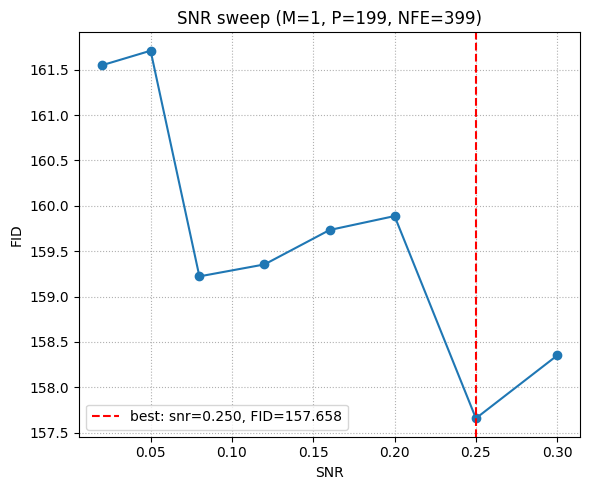

Best SNR for M=1: 0.25

=== SNR tuning: M = 2 ===
Tuning SNR for M=2: P=133, NFE=400


PC P=133,M=2,snr=0.020: 100%|██████████| 2000/2000 [00:06<00:00, 287.67it/s]


  snr=0.020  FID=217.134


PC P=133,M=2,snr=0.050: 100%|██████████| 2000/2000 [00:06<00:00, 287.68it/s]


  snr=0.050  FID=216.811


...

  snr=0.200  FID=212.823


PC P=133,M=2,snr=0.250: 100%|██████████| 2000/2000 [00:06<00:00, 287.66it/s]


  snr=0.250  FID=212.683


PC P=133,M=2,snr=0.300: 100%|██████████| 2000/2000 [00:06<00:00, 287.59it/s]


  snr=0.300  FID=212.605


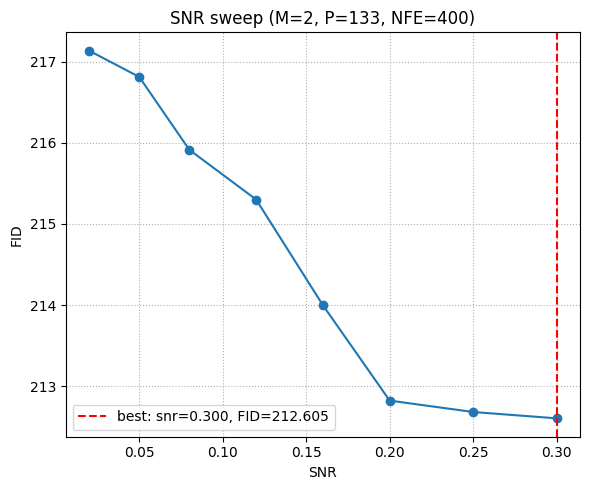

Best SNR for M=2: 0.3


In [ ]:
def tune_snr(M, snr_values, total_nfe=400, n_samples=2000):
    P = (total_nfe - 1) // (1 + M)
    actual = P * (1 + M) + 1
    print(f"Tuning SNR for M={M}: P={P}, NFE={actual}")
    results = {}
    for snr in snr_values:
        torch.manual_seed(11111 + M * 1000)
        if device.type == "cuda":
            torch.cuda.manual_seed_all(11111 + M * 1000)
        samples = generate_pc_samples(
            score_model, marginal_prob_std_fn, diffusion_coeff_fn,
            n_samples=n_samples,
            num_predictor_steps=P, num_corrector_steps=M, snr=snr,
        )
        results[snr] = compute_fid(samples, real_stats, device=device)
        print(f"  snr={snr:.3f}  FID={results[snr]:.3f}")
    return results, P, actual


def plot_snr_sweep(snr_results, M, P, nfe, save_path):
    snrs = np.array(sorted(snr_results.keys()))
    fids = np.array([snr_results[s] for s in snrs])
    best_snr = float(snrs[fids.argmin()])
    plt.figure(figsize=(6, 5))
    plt.plot(snrs, fids, "o-")
    plt.axvline(best_snr, color="red", ls="--",
                label=f"best: snr={best_snr:.3f}, FID={fids.min():.3f}")
    plt.xlabel("SNR"); plt.ylabel("FID")
    plt.title(f"SNR sweep (M={M}, P={P}, NFE={nfe})")
    plt.grid(True, ls=":"); plt.legend(); plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight"); plt.show()
    return best_snr


snr_grid = [0.02, 0.05, 0.08, 0.12, 0.16, 0.20, 0.25, 0.30]

print("\n=== SNR tuning: M = 1 ===")
snr_results_M1, P_M1, nfe_M1 = tune_snr(M=1, snr_values=snr_grid)
best_snr_M1 = plot_snr_sweep(snr_results_M1, M=1, P=P_M1, nfe=nfe_M1,
                             save_path="snr_sweep_M1.pdf")
print(f"Best SNR for M=1: {best_snr_M1}")

print("\n=== SNR tuning: M = 2 ===")
snr_results_M2, P_M2, nfe_M2 = tune_snr(M=2, snr_values=snr_grid)
best_snr_M2 = plot_snr_sweep(snr_results_M2, M=2, P=P_M2, nfe=nfe_M2,
                             save_path="snr_sweep_M2.pdf")
print(f"Best SNR for M=2: {best_snr_M2}")

In the matched-NFE comparison, there are 3 samplers at the same total NFE:
1. Euler-Maruyama:       num_steps = nfe - 1                  (steps + Tweedie)
2. Predictor-Corrector (M=1):  P = (nfe - 1) // 2                   (P predictor + P corrector + Tweedie)
3. Predictor-Corrector (M=2):  P = (nfe - 1) // 3                   (P predictor + 2P corrector + Tweedie)

NFE budgets are chosen so (NFE - 1) is divisible by 6 i.e. both 2 & 3, keeping all three at
exactly the same NFE.


In [ ]:
NFE_BUDGETS = [121, 241, 481, 961]


def run_matched_nfe(nfe_budgets, n_samples=5000, n_seeds=3):
    configs = lambda nfe: [
        ("EM",       "em", nfe - 1,         0, None),
        ("PC (M=1)", "pc", (nfe - 1) // 2, 1, best_snr_M1),
        ("PC (M=2)", "pc", (nfe - 1) // 3, 2, best_snr_M2),
    ]
    results = {label: {} for label, *_ in configs(nfe_budgets[0])}

    for nfe in nfe_budgets:
        print(f"\n--- NFE budget = {nfe} ---")
        for label, kind, P, M, snr in configs(nfe):
            fid_runs = []
            for seed_idx in range(n_seeds):
                torch.manual_seed(seed_idx * 1000 + nfe + M * 7)
                if device.type == "cuda":
                    torch.cuda.manual_seed_all(seed_idx * 1000 + nfe + M * 7)

                if kind == "em":
                    samples = generate_em_samples(
                        score_model, marginal_prob_std_fn, diffusion_coeff_fn,
                        n_samples=n_samples, num_steps=P,
                    )
                else:
                    samples = generate_pc_samples(
                        score_model, marginal_prob_std_fn, diffusion_coeff_fn,
                        n_samples=n_samples,
                        num_predictor_steps=P, num_corrector_steps=M, snr=snr,
                    )
                fid = compute_fid(samples, real_stats, device=device)
                fid_runs.append(fid)
                print(f"  {label}  seed={seed_idx}  FID={fid:.3f}")

            arr = np.array(fid_runs)
            results[label][nfe] = {
                "fid_mean": float(arr.mean()),
                "fid_std":  float(arr.std(ddof=1) if len(arr) > 1 else 0.0),
                "fid_runs": fid_runs,
            }
            print(f"  {label} @ NFE={nfe}: "
                  f"FID = {results[label][nfe]['fid_mean']:.3f} "
                  f"± {results[label][nfe]['fid_std']:.3f}")
    return results


print("\n=== Matched-NFE comparison ===")
nfe_results = run_matched_nfe(NFE_BUDGETS, n_samples=5000, n_seeds=3)

# Save raw numbers.
save_dict = {
    "nfe_budgets": np.array(NFE_BUDGETS),
    "best_snr_M1": np.array([best_snr_M1]),
    "best_snr_M2": np.array([best_snr_M2]),
}
for label, data in nfe_results.items():
    safe = label.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
    save_dict[f"{safe}_fid_mean"] = np.array([data[n]["fid_mean"] for n in NFE_BUDGETS])
    save_dict[f"{safe}_fid_std"]  = np.array([data[n]["fid_std"]  for n in NFE_BUDGETS])
np.savez("nfe_results.npz", **save_dict)
print("Saved raw results to nfe_results.npz")


=== Matched-NFE comparison ===

--- NFE budget = 121 ---


EM N=120: 100%|██████████| 5000/5000 [00:05<00:00, 948.29it/s]


  EM  seed=0  FID=236.384


EM N=120: 100%|██████████| 5000/5000 [00:05<00:00, 948.90it/s]


  EM  seed=1  FID=235.490


...

  PC (M=2)  seed=0  FID=99.040


PC P=320,M=2,snr=0.300: 100%|██████████| 5000/5000 [00:41<00:00, 119.07it/s]


  PC (M=2)  seed=1  FID=99.458


PC P=320,M=2,snr=0.300: 100%|██████████| 5000/5000 [00:41<00:00, 119.07it/s]


  PC (M=2)  seed=2  FID=99.615
  PC (M=2) @ NFE=961: FID = 99.371 ± 0.297
Saved raw results to nfe_results.npz


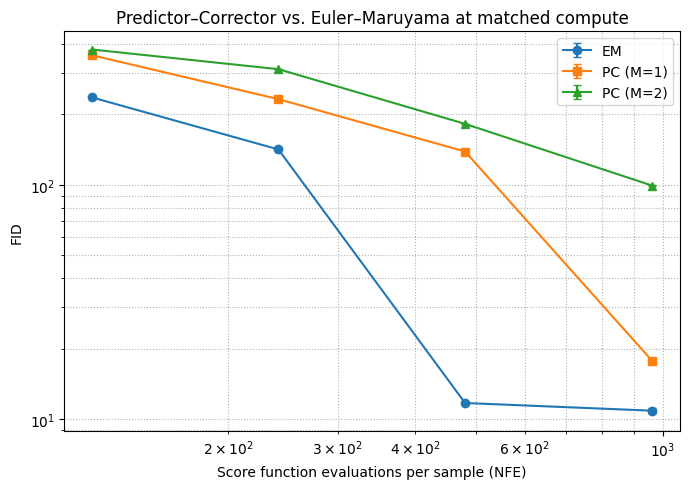


     NFE |                 EM |           PC (M=1) |           PC (M=2)
------------------------------------------------------------------------
     121 |      236.16 ± 0.59 |      357.58 ± 0.72 |      378.47 ± 0.08
     241 |      141.70 ± 0.48 |      232.40 ± 0.37 |      311.98 ± 0.50
     481 |       11.71 ± 0.11 |      138.85 ± 0.32 |      182.23 ± 0.17
     961 |       10.86 ± 0.24 |       17.76 ± 0.09 |       99.37 ± 0.30


In [ ]:
def plot_matched_nfe(nfe_results, save_path="matched_nfe.pdf"):
    plt.figure(figsize=(7, 5))
    markers = {"EM": "o", "PC (M=1)": "s", "PC (M=2)": "^"}
    for label, data in nfe_results.items():
        nfes = np.array(sorted(data.keys()))
        mu = np.array([data[n]["fid_mean"] for n in nfes])
        sd = np.array([data[n]["fid_std"]  for n in nfes])
        plt.errorbar(nfes, mu, yerr=sd, fmt=markers.get(label, "o") + "-",
                     capsize=3, label=label)
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("Score function evaluations per sample (NFE)")
    plt.ylabel("FID")
    plt.title("Predictor–Corrector vs. Euler–Maruyama at matched compute")
    plt.grid(True, which="both", ls=":")
    plt.legend(); plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight"); plt.show()


plot_matched_nfe(nfe_results)

# Summary table.
print("\n" + "=" * 72)
print(f"{'NFE':>8} | {'EM':>18} | {'PC (M=1)':>18} | {'PC (M=2)':>18}")
print("-" * 72)
for nfe in NFE_BUDGETS:
    em  = nfe_results["EM"][nfe]
    pc1 = nfe_results["PC (M=1)"][nfe]
    pc2 = nfe_results["PC (M=2)"][nfe]
    s_em  = f"{em['fid_mean']:.2f} ± {em['fid_std']:.2f}"
    s_pc1 = f"{pc1['fid_mean']:.2f} ± {pc1['fid_std']:.2f}"
    s_pc2 = f"{pc2['fid_mean']:.2f} ± {pc2['fid_std']:.2f}"
    print(f"{nfe:>8} | {s_em:>18} | {s_pc1:>18} | {s_pc2:>18}")
print("=" * 72)
